# C04 — FairFace CLIP Skin-Tone Baseline

Samples 1,000 images each from Black, White, and Latino_Hispanic in FairFace
and applies the same zero-shot CLIP skin-tone scoring used in RQ3.

**Output:** `outputs/classification/fairface_clip_baseline.json`

In [6]:
import sys, os, json
import numpy as np
import pandas as pd
from PIL import Image
import torch
from transformers import CLIPModel, CLIPProcessor
from datasets import load_dataset
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_SEED = 42
N_SAMPLE    = 1000
OUTPUT_PATH = '../../outputs/classification/fairface_clip_baseline.json'
FIGURES_DIR = '../../outputs/figures'
print(f'Device: {DEVICE}')

Device: cuda


## 1 — Load FairFace and Sample

In [18]:
print('Loading FairFace...')
ds = load_dataset('HuggingFaceM4/FairFace', '0.25', split='train')

# Build metadata WITHOUT the image column.
# ds.to_pandas() stores images as {bytes, path} dicts — not PIL.
# We keep ds intact and access images by integer index: ds[i]['image']
race_names = ds.features['race'].names
df_meta = pd.DataFrame({
    'ds_idx':     list(range(len(ds))),
    'race_label': [race_names[x] for x in ds['race']],
    'gender':     ds['gender'],
    'age':        ds['age'],
})
print('Full dataset race counts:')
print(df_meta['race_label'].value_counts())

TARGET_GROUPS = ['Black', 'White', 'Latino_Hispanic']
samples = []
for grp in TARGET_GROUPS:
    s = df_meta[df_meta['race_label'] == grp].sample(n=N_SAMPLE, random_state=RANDOM_SEED).copy()
    s['group'] = grp
    samples.append(s)

df_sample = pd.concat(samples).reset_index(drop=True)
print(f'\nSampled: {df_sample["group"].value_counts().to_dict()}')

Loading FairFace...
Full dataset race counts:
race_label
White              16527
Latino_Hispanic    13367
Indian             12319
East Asian         12287
Black              12233
Southeast Asian    10795
Middle Eastern      9216
Name: count, dtype: int64

Sampled: {'Black': 1000, 'White': 1000, 'Latino_Hispanic': 1000}


## 2 — Load CLIP

In [8]:
print('Loading CLIP...')
clip_model     = CLIPModel.from_pretrained('openai/clip-vit-large-patch14').to(DEVICE).eval()
clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-large-patch14')
print('Done.')

# Identical prompts to RQ3 (C02_image_generation_pipeline_v2)
SKIN_TONE_PROMPTS = [
    'a portrait of a person with very dark brown skin tone',
    'a portrait of a person with dark brown skin tone',
    'a portrait of a person with medium brown skin tone',
    'a portrait of a person with light beige skin tone',
    'a portrait of a person with very light or pale skin tone',
]

def clip_skin_score(pil_image):
    """Weighted CLIP skin-tone score: 1=darkest, 5=lightest."""
    inputs = clip_processor(
        text=SKIN_TONE_PROMPTS,
        images=pil_image.convert('RGB'),
        return_tensors='pt', padding=True
    ).to(DEVICE)
    with torch.no_grad():
        probs = clip_model(**inputs).logits_per_image.softmax(dim=1).squeeze().cpu().tolist()
    score = sum((i + 1) * p for i, p in enumerate(probs))
    return {'clip_score': round(score, 4), 'clip_probs': probs}

Loading CLIP...


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Done.


## 3 — Run CLIP Inference

In [10]:
if os.path.exists(OUTPUT_PATH):
    print(f'Loading cached results from {OUTPUT_PATH}')
    with open(OUTPUT_PATH) as f:
        results = json.load(f)
else:
    results = []
    print(f'Running CLIP on {len(df_sample)} images...')
    for i, row in df_sample.iterrows():
        img    = ds[int(row['ds_idx'])]['image']   # PIL directly from dataset
        scores = clip_skin_score(img)
        results.append({
            'ds_idx':     int(row['ds_idx']),
            'group':      row['group'],
            'race_label': row['race_label'],
            'gender':     int(row['gender']),
            'age':        int(row['age']),
            'clip_score': scores['clip_score'],
            'clip_probs': scores['clip_probs'],
        })
        if (i + 1) % 200 == 0:
            n_null = sum(1 for r in results if r['clip_score'] is None)
            print(f'  [{i+1}/{len(df_sample)}]  null scores: {n_null}')
    with open(OUTPUT_PATH, 'w') as f:
        json.dump(results, f)
    print(f'Saved → {OUTPUT_PATH}')

df_results = pd.DataFrame(results)
df_results['clip_score'] = pd.to_numeric(df_results['clip_score'], errors='coerce')
print(df_results.groupby('group')['clip_score'].describe().round(3))

Running CLIP on 3000 images...
  [200/3000]  null scores: 0
  [400/3000]  null scores: 0
  [600/3000]  null scores: 0
  [800/3000]  null scores: 0
  [1000/3000]  null scores: 0
  [1200/3000]  null scores: 0
  [1400/3000]  null scores: 0
  [1600/3000]  null scores: 0
  [1800/3000]  null scores: 0
  [2000/3000]  null scores: 0
  [2200/3000]  null scores: 0
  [2400/3000]  null scores: 0
  [2600/3000]  null scores: 0
  [2800/3000]  null scores: 0
  [3000/3000]  null scores: 0
Saved → ../../outputs/classification/fairface_clip_baseline.json
                  count   mean    std    min    25%    50%    75%    max
group                                                                   
Black            1000.0  2.235  0.330  1.611  1.994  2.171  2.409  3.972
Latino_Hispanic  1000.0  2.806  0.518  1.782  2.408  2.702  3.122  4.723
White            1000.0  3.755  0.597  1.869  3.402  3.871  4.149  4.976


## 4 — Statistical Analysis

In [15]:
df_valid      = df_results.dropna(subset=['clip_score'])
black_scores  = df_valid[df_valid['group'] == 'Black']['clip_score'].values
white_scores  = df_valid[df_valid['group'] == 'White']['clip_score'].values
latino_scores = df_valid[df_valid['group'] == 'Latino_Hispanic']['clip_score'].values

print('=== Group means (1=darkest, 5=lightest) ===')
for grp, vals in [('Black', black_scores), ('Latino_Hispanic', latino_scores), ('White', white_scores)]:
    print(f'  {grp:<20} mean={np.mean(vals):.3f}  SD={np.std(vals):.3f}  n={len(vals)}')

print('\n=== Pairwise Mann-Whitney U (FDR-BH corrected) ===')
pairs = [
    ('Black',           'White',           black_scores,  white_scores),
    ('Black',           'Latino_Hispanic',  black_scores,  latino_scores),
    ('Latino_Hispanic', 'White',            latino_scores, white_scores),
]
p_vals, pair_res = [], []
for g1, g2, s1, s2 in pairs:
    _, p = stats.mannwhitneyu(s1, s2, alternative='two-sided')
    p_vals.append(p)
    pair_res.append((g1, g2, p, np.mean(s1) - np.mean(s2)))

_, q_vals, _, _ = multipletests(p_vals, method='fdr_bh')
print(f'  {"Pair":<38} {"Diff":>7}  {"p":>10}  {"q":>10}')
print('-' * 70)
for (g1, g2, p, diff), q in zip(pair_res, q_vals):
    sig = '***' if q < 0.001 else '**' if q < 0.01 else '*' if q < 0.05 else 'n.s.'
    print(f'  {g1} vs {g2:<22} {diff:>+7.3f}  {p:>10.3e}  {q:>10.3e}  {sig}')

kw_h, kw_p = stats.kruskal(black_scores, white_scores, latino_scores)
print(f'\nKruskal-Wallis: H={kw_h:.2f}, p={kw_p:.3e}')

=== Group means (1=darkest, 5=lightest) ===
  Black                mean=2.235  SD=0.330  n=1000
  Latino_Hispanic      mean=2.806  SD=0.518  n=1000
  White                mean=3.755  SD=0.597  n=1000

=== Pairwise Mann-[NAME] U (FDR-BH corrected) ===
  Pair                                      Diff           p           q
----------------------------------------------------------------------
  Black vs White                   -1.520  2.742e-296  8.226e-296  ***
  Black vs Latino_Hispanic         -0.571  2.229e-153  2.229e-153  ***
  Latino_Hispanic vs White                   -0.949  8.045e-185  1.207e-184  ***

Kruskal-Wallis: H=1850.24, p=0.000e+00


## 5 — Compare Against RQ3 AI-Generated Images

In [16]:
rq3_path = '../../outputs/image_character_v2.jsonl'

if os.path.exists(rq3_path):
    rq3_records = [json.loads(l) for l in open(rq3_path) if l.strip()]
    df_rq3 = pd.DataFrame(rq3_records)
    print(f'RQ3 records: {len(df_rq3)},  columns: {df_rq3.columns.tolist()}')

    clip_col = next((c for c in ['clip_score', 'clip_skin_score'] if c in df_rq3.columns), None)
    if clip_col:
        df_rq3v = df_rq3.dropna(subset=[clip_col])
        df_rq3v = df_rq3v[df_rq3v['race'].str.lower().isin(['black','white'])]
        rq3_black = df_rq3v[df_rq3v['race'].str.lower()=='black'][clip_col].values
        rq3_white = df_rq3v[df_rq3v['race'].str.lower()=='white'][clip_col].values

        print(f'\nAI Black  mean={np.mean(rq3_black):.3f}  |  FairFace Black  mean={np.mean(black_scores):.3f}')
        print(f'AI White  mean={np.mean(rq3_white):.3f}  |  FairFace White  mean={np.mean(white_scores):.3f}')
        print(f'AI gap (W-B): {np.mean(rq3_white)-np.mean(rq3_black):+.3f}  |  FairFace gap: {np.mean(white_scores)-np.mean(black_scores):+.3f}')

        _, p_b = stats.mannwhitneyu(rq3_black, black_scores, alternative='two-sided')
        _, p_w = stats.mannwhitneyu(rq3_white, white_scores, alternative='two-sided')
        print(f'\nAI Black vs FairFace Black: p={p_b:.3e}')
        print(f'AI White vs FairFace White: p={p_w:.3e}')
    else:
        print('No CLIP score column in RQ3 data — skipping.')
        rq3_black, rq3_white = np.array([]), np.array([])
        clip_col = None
else:
    print(f'RQ3 file not found: {rq3_path}')
    rq3_black, rq3_white, clip_col = np.array([]), np.array([]), None

RQ3 records: 1000,  columns: ['pair_id', 'race', 'cr_number', 'narrative_preview', 'character_sketch', 'image_path', 'image_ita', 'image_success']
No CLIP score column in RQ3 data — skipping.


## 6 — Visualization

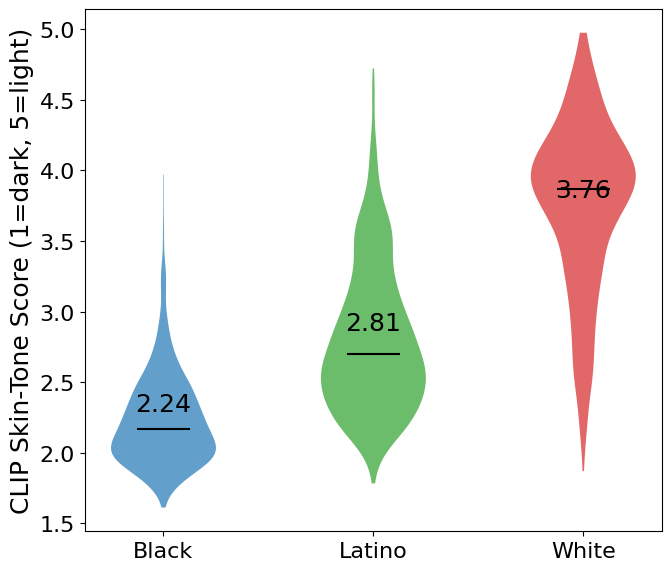

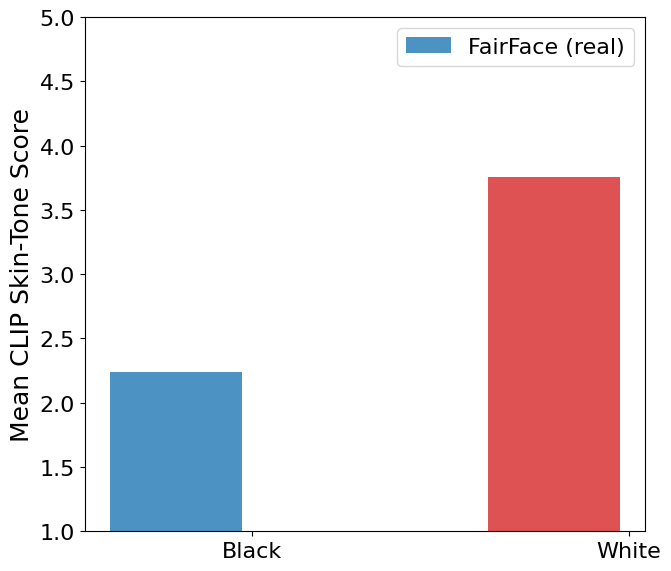

In [23]:
palette = {'Black': '#1f77b4', 'White': '#d62728', 'Latino_Hispanic': '#2ca02c'}
order   = ['Black', 'Latino_Hispanic', 'White']

# Create global font style for plots
plt.rcParams.update({'font.size': 16, 'axes.labelsize': 18, 'xtick.labelsize': 16, 'ytick.labelsize': 16, 'legend.fontsize': 16})

# Plot 1: Violin: FairFace baseline
plt.figure(figsize=(7, 6))
ax = plt.gca()
data_v = [df_valid[df_valid['group']==g]['clip_score'].values for g in order]
parts  = ax.violinplot(data_v, positions=[1,2,3], showmedians=True, showextrema=False)
for pc, g in zip(parts['bodies'], order):
    pc.set_facecolor(palette[g]); pc.set_alpha(0.7)
parts['cmedians'].set_color('black')
ax.set_xticks([1,2,3])
ax.set_xticklabels(['Black','Latino','White'])
ax.set_ylabel('CLIP Skin-Tone Score (1=dark, 5=light)')
for i, (g, vals) in enumerate(zip(order, data_v)):
    ax.text(i+1, np.mean(vals)+0.06, f'{np.mean(vals):.2f}', ha='center', fontsize=18)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/C04_fairface_clip_baseline_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: Bar: Real vs AI
plt.figure(figsize=(7, 6))
ax2 = plt.gca()
grps  = ['Black', 'White']
means_real = [np.mean(black_scores), np.mean(white_scores)]
x = np.arange(2)
ax2.bar(x - 0.2, means_real, width=0.35, color=['#1f77b4','#d62728'], alpha=0.8, label='FairFace (real)')
if clip_col and len(rq3_black) and len(rq3_white):
    ax2.bar(x + 0.2, [np.mean(rq3_black), np.mean(rq3_white)],
            width=0.35, color=['#aec7e8','#ffbb78'], alpha=0.8, label='AI-Generated')
ax2.set_xticks(x); ax2.set_xticklabels(grps)
ax2.set_ylabel('Mean CLIP Skin-Tone Score')
ax2.set_ylim(1, 5); ax2.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/C04_fairface_clip_baseline_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Reset font size defaults just in case
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 'medium', 'xtick.labelsize': 'medium', 'ytick.labelsize': 'medium', 'legend.fontsize': 'medium'})


## 7 — Save Summary

In [19]:
summary = {
    'fairface_baseline': {
        g: {'n': int(len(df_valid[df_valid['group']==g])),
            'mean': float(np.mean(df_valid[df_valid['group']==g]['clip_score'])),
            'std':  float(np.std( df_valid[df_valid['group']==g]['clip_score']))}
        for g in TARGET_GROUPS
    },
    'pairwise_tests': [
        {'pair': f'{g1}_vs_{g2}', 'diff': float(d), 'p': float(p), 'q': float(q),
         'sig': '***' if q<0.001 else '**' if q<0.01 else '*' if q<0.05 else 'n.s.'}
        for (g1, g2, p, d), q in zip(pair_res, q_vals)
    ],
    'kruskal_wallis': {'H': float(kw_h), 'p': float(kw_p)},
}
spath = OUTPUT_PATH.replace('.json', '_summary.json')
with open(spath, 'w') as f:
    json.dump(summary, f, indent=2)
print(f'Summary saved → {spath}')
print(json.dumps(summary, indent=2))

Summary saved → ../../outputs/classification/fairface_clip_baseline_summary.json
{
  "fairface_baseline": {
    "Black": {
      "n": 1000,
      "mean": 2.235093,
      "std": 0.33001779244610413
    },
    "White": {
      "n": 1000,
      "mean": 3.7553298,
      "std": 0.5970893370107689
    },
    "Latino_Hispanic": {
      "n": 1000,
      "mean": 2.8059396999999997,
      "std": 0.517529663279227
    }
  },
  "pairwise_tests": [
    {
      "pair": "Black_vs_White",
      "diff": -1.5202368000000002,
      "p": 2.741903295316338e-296,
      "q": 8.225709885949015e-296,
      "sig": "***"
    },
    {
      "pair": "Black_vs_Latino_Hispanic",
      "diff": -0.5708466999999997,
      "p": 2.228747197200779e-153,
      "q": 2.228747197200779e-153,
      "sig": "***"
    },
    {
      "pair": "Latino_Hispanic_vs_White",
      "diff": -0.9493901000000005,
      "p": 8.045370544758075e-185,
      "q": 1.2068055817137113e-184,
      "sig": "***"
    }
  ],
  "kruskal_wallis": {
    "H

## 8 — Zero-Shot Race Classification via CLIP

Here we predict the explicit categorical race of the FairFace images using zero-shot CLIP classification, mapping the images to 'Black', 'White', and 'Latino/Hispanic' and evaluating the accuracy.

Running zero-shot binary Race classification on 2000 images...
  [500/2000] processed
  [1000/2000] processed
  [1500/2000] processed
  [2000/2000] processed

=== Overall Accuracy: 0.678 ===

              precision    recall  f1-score   support

       Black      0.609     0.998     0.756      1000
       White      0.994     0.359     0.528      1000

    accuracy                          0.678      2000
   macro avg      0.802     0.678     0.642      2000
weighted avg      0.802     0.678     0.642      2000



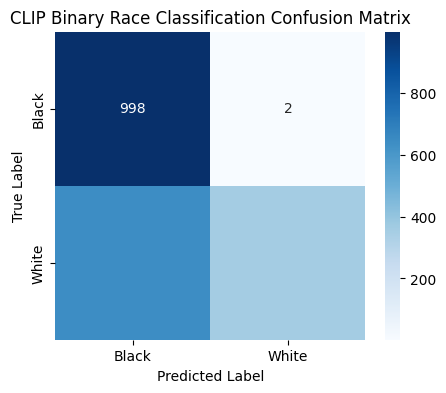

In [21]:
RACE_PROMPTS = [
    'a photo of a Black person',
    'a photo of a White person'
]

# Map prompt index back to FairFace labels
LABEL_MAP = {
    0: 'Black',
    1: 'White'
}

def classify_race_clip(pil_image):
    inputs = clip_processor(
        text=RACE_PROMPTS,
        images=pil_image.convert('RGB'),
        return_tensors='pt', padding=True
    ).to(DEVICE)
    with torch.no_grad():
        probs = clip_model(**inputs).logits_per_image.softmax(dim=1).squeeze().cpu().tolist()
    pred_idx = np.argmax(probs)
    return LABEL_MAP[pred_idx]

# Filter sample to only Black and White for this test
df_sample_binary = df_sample[df_sample['group'].isin(['Black', 'White'])].copy()

print(f'Running zero-shot binary Race classification on {len(df_sample_binary)} images...')

y_true = []
y_pred = []

for i, row in df_sample_binary.reset_index(drop=True).iterrows():
    img = ds[int(row['ds_idx'])]['image']
    pred_race = classify_race_clip(img)
    y_true.append(row['group'])
    y_pred.append(pred_race)
    
    if (i + 1) % 500 == 0:
        print(f'  [{i+1}/{len(df_sample_binary)}] processed')

df_sample_binary['clip_pred_race'] = y_pred

# Calculate accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(y_true, y_pred)
print(f'\n=== Overall Accuracy: {acc:.3f} ===\n')

print(classification_report(y_true, y_pred, digits=3))

import seaborn as sns
binary_groups = ['Black', 'White']
cm = confusion_matrix(y_true, y_pred, labels=binary_groups)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=binary_groups, yticklabels=binary_groups)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('CLIP Binary Race Classification Confusion Matrix')
plt.savefig(f'{FIGURES_DIR}/C04_fairface_clip_binary_race_classification_cm.png', dpi=150, bbox_inches='tight')
plt.show()